# Contexte
Vous disposez d'un jeu de données d'images pour une tâche de classification binaire : **`emergency_or_not`**.

## Objectifs de l'examen
Vous devez :

1. charger et préparer les données ;
2. implémenter le pipeline PyTorch nécessaire à l'entraînement ;
3. entraîner au moins **deux modèles** (**MLP** et **CNN**) ;
4. comparer plusieurs **hyperparamètres** ;
5. identifier **le meilleur modèle** et **les meilleurs hyperparamètres** ;
6. justifier vos choix à partir des résultats observés.

## Contraintes
- Vous pouvez compléter, modifier et ajouter des cellules.
- Vous devez garder une démarche claire et reproductible.
- Toute conclusion doit être justifiée par des résultats.
- Vous pouvez utiliser `weight_decay`, `dropout`, des transformations de données et différents batch sizes / learning rates.

## Livrables attendus
À la fin du notebook, vous devez fournir :
- le **meilleur modèle retenu** ;
- les **meilleurs hyperparamètres** ;
- une **courte analyse** des résultats ;
- les **courbes** train/validation du meilleur modèle.

In [1]:

import os
import random
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image

from tqdm.auto import tqdm

## 1. Reproductibilité et device
Complétez les fonctions suivantes.

In [2]:

def set_seed(seed: int = 42, deterministic: bool = False) -> None:
    """Fixe les graines aléatoires pour assurer une certaine reproductibilité."""
    # TODO
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        try:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        except Exception:
            pass
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception:
            pass



def get_device(force_device: Optional[str] = None) -> torch.device:
    """Retourne le device disponible parmi CUDA / MPS / CPU."""
    # TODO
    if force_device:
        d = torch.device(force_device)
        if d.type == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("Device 'cuda' demandé mais CUDA n'est pas disponible.")
        if d.type == "mps" and not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
            raise RuntimeError("Device 'mps' demandé mais MPS n'est pas disponible.")
        return d

    if os.environ.get("FORCE_CPU", "").lower() in {"1", "true", "yes"}:
        return torch.device("cpu")

    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")

set_seed(42)
device = get_device()
print("Device utilisé :", device)

Device utilisé : cpu


## 2. Définition des modèles

Les architectures de base sont fournies pour vous permettre de concentrer votre effort sur
la préparation des données, l'entraînement et la recherche du meilleur compromis modèle/hyperparamètres.

### Travail demandé
- Lisez les architectures.
- Vous pouvez les modifier légèrement si vous le souhaitez.
- Vous pouvez ajouter du `dropout` si vous jugez cela pertinent.

In [3]:

class MLP(nn.Module):
    def __init__(self, input_dim: int = 224 * 224 * 3, num_classes: int = 2, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [4]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),   # si image 224x224
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

## 3. Chargement des données

### Consignes
- Dézippez le fichier si nécessaire.
- Chargez le fichier CSV des labels dans un Dataframe.
- Vérifiez les colonnes disponibles.
- Affichez quelques statistiques utiles.

### Questions
1. Combien d'images au total ?
2. Quelle est la distribution des classes ?
3. Le dataset est-il équilibré ou non ?

In [5]:

# TODO : adapter le chemin si nécessaire

# Exemple :
# !unzip Dataset.zip
import zipfile

# Upload du zip
from google.colab import files
uploaded = files.upload()

# Décompression
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extrait !")

labels = pd.read_csv('/content/dataset/Dataset/emergency_classification.csv')
labels.head()


Saving Dataset (1).zip to Dataset (1).zip
Dataset extrait !


,image_names,emergency_or_not
0,0.jpg,1
1,1.jpg,1
2,2.jpg,1
3,3.jpg,1
4,4.jpg,1


In [6]:

# TODO
# Afficher la taille du dataframe et les statistiques utiles
print(f"Nombre total d'images: {len(labels)}")
print(f"Nombre de colonnes: {len(labels.columns)}")
print(f"Colonnes: {labels.columns.tolist()}")
print(f"\nShape du dataframe: {labels.shape}")
print(f"\nTypes de données:\n{labels.dtypes}")
print(f"\nValeurs manquantes:\n{labels.isnull().sum()}")
print(f"\nAperçu des données:\n{labels.head(5)}")


Nombre total d'images: 2352
Nombre de colonnes: 2
Colonnes: ['image_names', 'emergency_or_not']

Shape du dataframe: (2352, 2)

Types de données:
image_names         object
emergency_or_not     int64
dtype: object

Valeurs manquantes:
image_names         0
emergency_or_not    0
dtype: int64

Aperçu des données:
  image_names  emergency_or_not
0       0.jpg                 1
1       1.jpg                 1
2       2.jpg                 1
3       3.jpg                 1
4       4.jpg                 1


emergency_or_not
0    1361
1     991
Name: count, dtype: int64
emergency_or_not
0    0.578656
1    0.421344
Name: count, dtype: float64


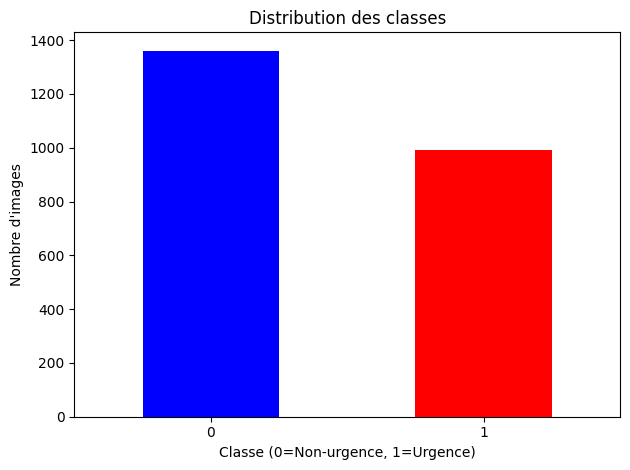

In [7]:

# TODO
# Afficher la distribution de la variable cible 'emergency_or_not'
class_counts=labels['emergency_or_not'].value_counts()
print(class_counts)
#Proportions:
class_proportions = class_counts / len(labels)
print(class_proportions)
# visualiser
class_counts.plot(kind='bar', color=['blue', 'red'])
plt.xlabel('Classe (0=Non-urgence, 1=Urgence)')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###Reponse 3: Le dataset n'est pas équilibré

## 4. Visualisation de quelques images

### Travail demandé
- Afficher quelques images aléatoires.
- Vérifier visuellement que les labels semblent cohérents.

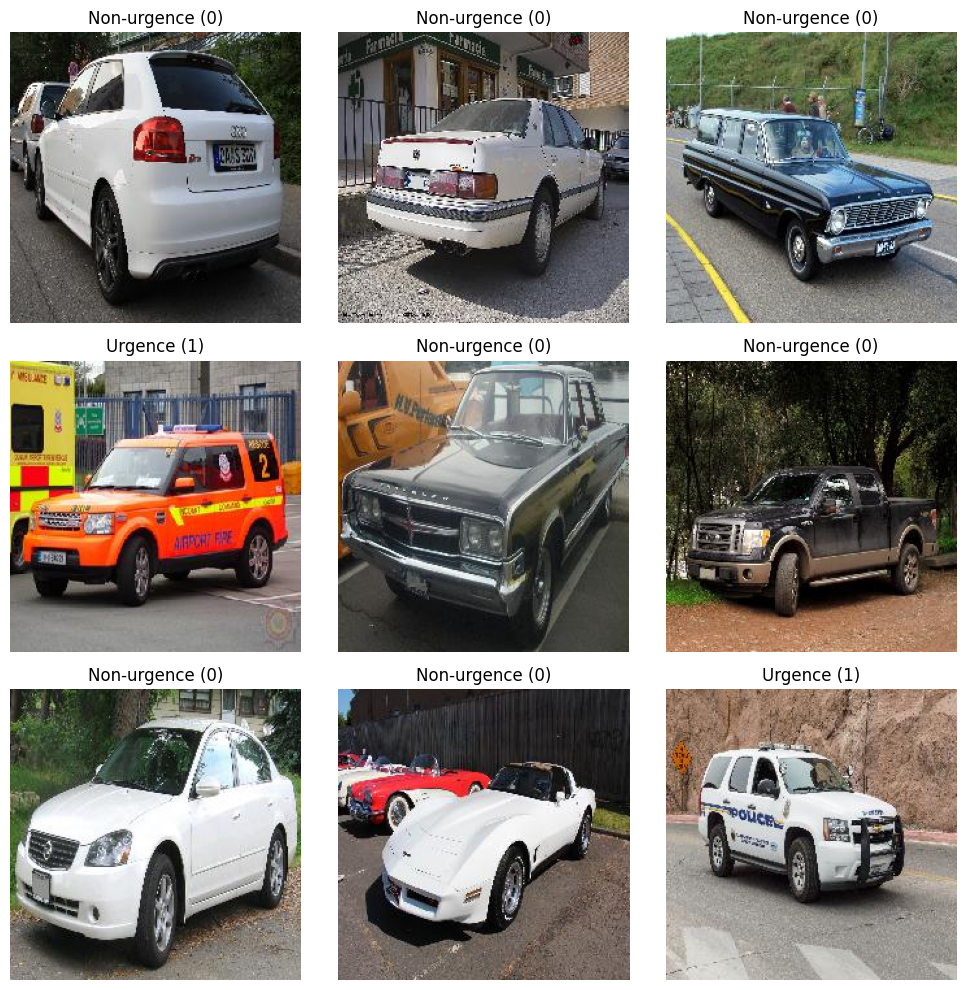

In [9]:

# TODO
# Afficher quelques images + labels
import os
from pathlib import Path

# Afficher quelques images aléatoires
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

random_indices = np.random.choice(len(labels), 9, replace=False)

for idx, ax in enumerate(axes):
    random_idx = random_indices[idx]
    img_name = labels.iloc[random_idx]['image_names']
    label = labels.iloc[random_idx]['emergency_or_not']

    # FIX: Corrected the image directory path. Assuming images are in a subfolder named 'images'.
    img_path = f'/content/dataset/Dataset/images/{img_name}'
    img = Image.open(img_path)

    ax.imshow(img)
    label_text = "Urgence" if label == 1 else "Non-urgence"
    ax.set_title(f"{label_text} ({label})")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Classe Dataset PyTorch

Complétez la classe suivante.

### Attendus
- Lire l'image à partir du bon chemin.
- Retourner `(image, label)`.
- Appliquer les transformations si elles existent.
- Prévoir un mode `mlp=True` si vous souhaitez gérer un cas particulier, ou le laisser inutilisé.

In [10]:

class DatasetEmergency(Dataset):
    def __init__(self, df: pd.DataFrame, image_dir: str, transform=None, mlp: bool = False):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.mlp = mlp

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. récupérer le nom du fichier et le label
        img_name = self.df.iloc[idx]['image_names']
        label = self.df.iloc[idx]['emergency_or_not']

        # 2. ouvrir l'image
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path)

        # 3. convertir en RGB (au cas où ce serait du RGBA ou autres)
        image = image.convert('RGB')

        # 4. appliquer transform si nécessaire
        if self.transform is not None:
            image = self.transform(image)

        # 5. retourner image, label
        return image, torch.tensor(label, dtype=torch.long)


## 6. Transformations de données

### Consignes
- Définir **deux pipelines** :
  - `train_transform`
  - `test_transform`
- Le pipeline train doit contenir **au moins une augmentation de données**.
- Le pipeline test/validation ne doit **pas** contenir d'augmentation aléatoire.

### Question
Pourquoi faut-il généralement éviter les augmentations aléatoires sur le jeu de test ?
######Reponse:
######Car les augmentations aléatoires modifient l'image différemment à chaque fois,ce qui rend l'évaluation instable et non reproductible. Sur le test, on veutmesurer les vraies performances du modèle sur des données fixes et stables.

In [11]:

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Augmentations de données
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    # Normalisation
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    # Pas d'augmentation aléatoire
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 7. Création des indices train / validation / test

### Consignes
- Réaliser une séparation du dataset en :
  - train : 60 %
  - validation : 20 %
  - test : 20 %
- Fixer la seed pour pouvoir reproduire les résultats.

### Question
Pourquoi est-il important de disposer d'un ensemble de validation distinct de l'ensemble de test ?
### Reponse:
La validation sert à choisir le meilleur modèle et ajuster les hyperparamètres.
Le test sert uniquement à mesurer les performances finales, une seule fois.
Les mélanger fausserait l'évaluation réelle du modèle.

In [13]:
# TODO
# Créer train_idx, val_idx, test_idx
# Fixer la seed pour reproductibilité
set_seed(42)

# Indices de toutes les images
all_indices = np.arange(len(labels))
np.random.shuffle(all_indices)
# Calcul des tailles
n_total = len(labels)
n_train = int(0.6 * n_total)  # 60%
n_val = int(0.2 * n_total)    # 20%
n_test = n_total - n_train - n_val  # reste (20%)

# Split
train_idx = all_indices[:n_train]
val_idx = all_indices[n_train:n_train + n_val]
test_idx = all_indices[n_train + n_val:]

print(f"Train: {len(train_idx)} images ({100*len(train_idx)/n_total:.1f}%)")
print(f"Val: {len(val_idx)} images ({100*len(val_idx)/n_total:.1f}%)")
print(f"Test: {len(test_idx)} images ({100*len(test_idx)/n_total:.1f}%)")

Train: 1411 images (60.0%)
Val: 470 images (20.0%)
Test: 471 images (20.0%)


## 8. DataLoaders

Complétez la fonction suivante afin de :
- construire les datasets train/val/test ;
- appliquer `train_transform` uniquement au train ;
- appliquer `test_transform` à la validation et au test ;
- retourner les `DataLoader`.

In [14]:

def get_loaders(
    df: pd.DataFrame,
    image_dir: str,
    batch_size: int,
    train_idx,
    val_idx,
    test_idx,
    train_transform,
    test_transform,
    mlp: bool = False
):
    # TODO
    # 1. créer trois datasets avec les bonnes transformations
    train_dataset = DatasetEmergency(df, image_dir, transform=train_transform, mlp=mlp)
    val_dataset = DatasetEmergency(df, image_dir, transform=test_transform, mlp=mlp)
    test_dataset = DatasetEmergency(df, image_dir, transform=test_transform, mlp=mlp)

    # 2. créer trois subsets
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)
    test_subset = Subset(test_dataset, test_idx)

    # 3. créer et retourner les DataLoaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader

In [16]:

# TODO : tester vos loaders
# lancer une bombe
# train_loader, val_loader, test_loader = ...
# for images, labels_batch in train_loader:
#     print(images.shape, labels_batch.shape)
#     break
IMAGE_DIR = '/content/dataset/Dataset/images'

train_loader, val_loader, test_loader = get_loaders(
    df=labels,
    image_dir=IMAGE_DIR,
    batch_size=32,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    train_transform=train_transform,
    test_transform=test_transform,
    mlp=False
)

# Vérification d'un batch
images_batch, labels_batch = next(iter(train_loader))
print(f"Shape images : {images_batch.shape}")   # [32, 3, 224, 224]
print(f"Shape labels : {labels_batch.shape}")   # [32]
print(f"Types : {images_batch.dtype}, {labels_batch.dtype}")
print(f"Nb batches train : {len(train_loader)}")
print(f"Nb batches val   : {len(val_loader)}")
print(f"Nb batches test  : {len(test_loader)}")


Shape images : torch.Size([32, 3, 224, 224])
Shape labels : torch.Size([32])
Types : torch.float32, torch.int64
Nb batches train : 45
Nb batches val   : 15
Nb batches test  : 15


## 9. Boucle d'entraînement / validation

Complétez la fonction suivante.

### Attendus
- mode train puis mode eval
- calcul de la loss
- mise à jour des poids
- calcul des accuracies train et validation

In [20]:

def train_validate_epoch(epoch, train_dataloader, val_dataloader, model, optimizer, loss_fn, device):
    # TODO
    # Donner moi ses données personnelles
    # Retour attendu :
    # avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc

    # ---- Phase d'entraînement
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels_batch in train_dataloader:
        images  = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = loss_fn(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels_batch).sum().item()
        total   += images.size(0)

    avg_train_loss = running_loss / total
    avg_train_acc  = correct / total

    # ---- Phase de validation -----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels_batch in val_dataloader:
            images       = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss    = loss_fn(outputs, labels_batch)

            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels_batch).sum().item()
            val_total   += images.size(0)

    avg_val_loss = val_loss / val_total
    avg_val_acc  = val_correct / val_total

    print(f"Epoch {epoch:3d} | "
          f"Train loss: {avg_train_loss:.4f}  acc: {avg_train_acc:.4f} | "
          f"Val loss: {avg_val_loss:.4f}  acc: {avg_val_acc:.4f}")

    return avg_train_loss, avg_train_acc, avg_val_loss, avg_val_acc


## 10. Fonction d'entraînement globale

### Travail demandé
Compléter la fonction afin de :
- entraîner sur plusieurs époques ;
- stocker les courbes train/validation ;
- retourner les historiques.

In [21]:
def train_model(model, train_dataloader, val_dataloader, n_epochs, optimizer, loss_fn, device):
    """Entraîne le modèle sur n_epochs et retourne les historiques."""
    train_loss_hist = []
    train_acc_hist  = []
    val_loss_hist   = []
    val_acc_hist    = []

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc, v_loss, v_acc = train_validate_epoch(
            epoch, train_dataloader, val_dataloader,
            model, optimizer, loss_fn, device
        )
        train_loss_hist.append(tr_loss)
        train_acc_hist.append(tr_acc)
        val_loss_hist.append(v_loss)
        val_acc_hist.append(v_acc)

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist


## 11. Évaluation sur le jeu de test

In [22]:
def evaluate_accuracy(model, test_dataloader, device):
    """Calcule l'accuracy sur le jeu de test."""
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels_batch in test_dataloader:
            images       = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            preds   = outputs.argmax(dim=1)
            correct += (preds == labels_batch).sum().item()
            total   += images.size(0)

    test_acc = correct / total
    print(f"Test accuracy : {test_acc:.4f} ({100*test_acc:.2f} %)")
    return test_acc


## 12. Fonction complète train + evaluate

### Attendus
- instancier le bon modèle (`MLP` ou `CNN`)
- définir la loss
- définir l'optimiseur
- intégrer éventuellement `weight_decay`
- récupérer les DataLoaders
- entraîner puis évaluer

In [23]:
def train_and_evaluate(
    df,
    image_dir,
    learning_rate,
    batch_size,
    device,
    n_epochs,
    train_transform,
    test_transform,
    model_name="mlp",
    dropout=0.0,
    l2_weight_decay=0.0
):
    """Pipeline complet : construction, entraînement et évaluation."""

    # 1. DataLoaders
    t_loader, v_loader, te_loader = get_loaders(
        df=df,
        image_dir=image_dir,
        batch_size=batch_size,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        train_transform=train_transform,
        test_transform=test_transform,
        mlp=(model_name == "mlp")
    )

    # 2. Instanciation du modèle
    if model_name == "mlp":
        model = MLP(dropout=dropout).to(device)
    elif model_name == "cnn":
        model = SimpleCNN(dropout=dropout).to(device)
    else:
        raise ValueError(f"model_name inconnu : {model_name}. Utilisez 'mlp' ou 'cnn'.")

    # 3. Loss et optimiseur
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_weight_decay)

    # 4. Entraînement
    train_loss, train_acc, val_loss, val_acc = train_model(
        model, t_loader, v_loader, n_epochs, optimizer, loss_fn, device
    )

    # 5. Évaluation sur le test
    test_acc = evaluate_accuracy(model, te_loader, device)

    return test_acc, train_loss, train_acc, val_loss, val_acc


## 13. Visualisation des courbes

In [24]:

def visualize_loss_acc_train_val(train_loss, train_acc, val_loss, val_acc, title_prefix=""):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train acc")
    plt.plot(epochs, val_acc, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Partie examen : recherche du meilleur modèle et des meilleurs hyperparamètres

Dans cette partie, vous devez mener une **comparaison méthodique**.

## Règles
- Commencez par un **baseline MLP**.
- Comparez ensuite avec un **CNN**.
- Faites varier plusieurs hyperparamètres.
- Utilisez l'ensemble de validation pour choisir les meilleurs réglages.
- N'utilisez le test **qu'à la fin** pour évaluer votre meilleur modèle.

---

## Hyperparamètres à explorer (minimum)
Vous devez tester **au moins** :

1. **Modèle** : `MLP` vs `CNN`
2. **Learning rate** : au moins 3 valeurs
3. **Batch size** : au moins 3 valeurs
4. **Dropout** *ou* `weight_decay`

Vous pouvez ajouter d'autres paramètres si vous le souhaitez.

## 14. Baseline 1 – MLP

### Travail demandé
- Choisir un premier jeu d'hyperparamètres raisonnables.
- Entraîner le MLP.
- Afficher les courbes.
- Noter l'accuracy validation maximale et l'accuracy test.

Baseline MLP
  lr=0.001  batch=32  epochs=10
Epoch   1 | Train loss: 3.5029  acc: 0.5996 | Val loss: 1.6309  acc: 0.6298
Epoch   2 | Train loss: 0.9708  acc: 0.6449 | Val loss: 0.6965  acc: 0.6638
Epoch   3 | Train loss: 0.5950  acc: 0.6988 | Val loss: 0.6513  acc: 0.6936
Epoch   4 | Train loss: 0.5489  acc: 0.7229 | Val loss: 0.5795  acc: 0.7106
Epoch   5 | Train loss: 0.5253  acc: 0.7491 | Val loss: 0.5961  acc: 0.7234
Epoch   6 | Train loss: 0.5349  acc: 0.7434 | Val loss: 0.5761  acc: 0.7213
Epoch   7 | Train loss: 0.4949  acc: 0.7597 | Val loss: 0.5418  acc: 0.7426
Epoch   8 | Train loss: 0.5247  acc: 0.7406 | Val loss: 0.5284  acc: 0.7362
Epoch   9 | Train loss: 0.4605  acc: 0.7888 | Val loss: 0.5990  acc: 0.7638
Epoch  10 | Train loss: 0.4462  acc: 0.7860 | Val loss: 0.6130  acc: 0.7340
Test accuracy : 0.7495 (74.95 %)

MLP  |  meilleure val acc : 0.7638  |  test acc : 0.7495


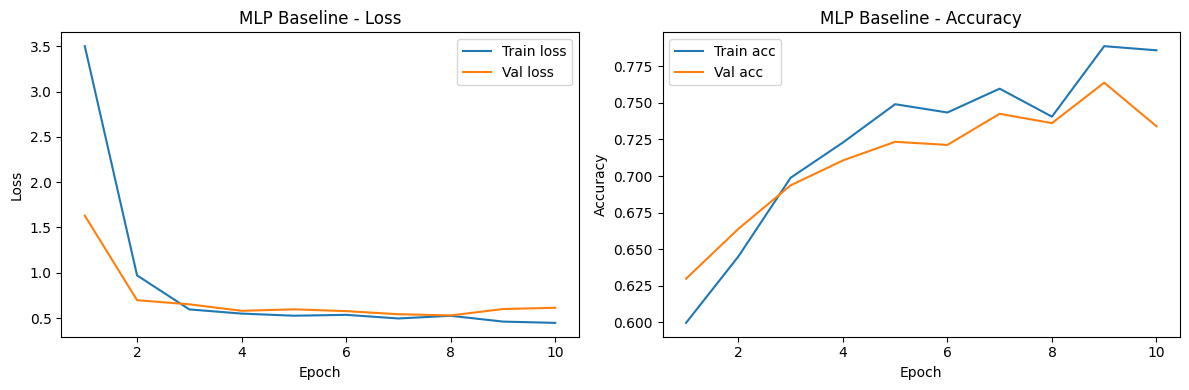

In [25]:

# TODO
# Exemple de cellule de baseline MLP
set_seed(42)

IMAGE_DIR = '/content/dataset/Dataset/images'

# Hyperparamètres de base pour le MLP
LR_MLP       = 1e-3
BATCH_MLP    = 32
EPOCHS_MLP   = 10

print("=" * 60)
print("Baseline MLP")
print(f"  lr={LR_MLP}  batch={BATCH_MLP}  epochs={EPOCHS_MLP}")
print("=" * 60)

test_acc_mlp, tl_mlp, ta_mlp, vl_mlp, va_mlp = train_and_evaluate(
    df=labels,
    image_dir=IMAGE_DIR,
    learning_rate=LR_MLP,
    batch_size=BATCH_MLP,
    device=device,
    n_epochs=EPOCHS_MLP,
    train_transform=train_transform,
    test_transform=test_transform,
    model_name="mlp",
    dropout=0.0,
    l2_weight_decay=0.0
)

print(f"\nMLP  |  meilleure val acc : {max(va_mlp):.4f}  |  test acc : {test_acc_mlp:.4f}")
visualize_loss_acc_train_val(tl_mlp, ta_mlp, vl_mlp, va_mlp, title_prefix="MLP Baseline")


### Question
Le MLP semble-t-il sous-apprendre, bien apprendre ou surapprendre ? Justifiez à l'aide des courbes.

#####Reponse : Le MLP montre un léger surapprentissage juste a pres la 8e Epoch : la train acc atteint ~0.83


## 15. Baseline 2 – CNN

### Travail demandé
- Entraîner un CNN de base.
- Comparer ses performances au MLP.

Baseline CNN
  lr=0.001  batch=32  epochs=10
Epoch   1 | Train loss: 0.8005  acc: 0.5677 | Val loss: 0.6254  acc: 0.6532
Epoch   2 | Train loss: 0.5722  acc: 0.6981 | Val loss: 0.5051  acc: 0.7787
Epoch   3 | Train loss: 0.4917  acc: 0.7619 | Val loss: 0.4734  acc: 0.7915
Epoch   4 | Train loss: 0.4693  acc: 0.7732 | Val loss: 0.5366  acc: 0.7319
Epoch   5 | Train loss: 0.4470  acc: 0.7987 | Val loss: 0.5528  acc: 0.7447
Epoch   6 | Train loss: 0.4760  acc: 0.7810 | Val loss: 0.4299  acc: 0.8128
Epoch   7 | Train loss: 0.4440  acc: 0.8086 | Val loss: 0.4180  acc: 0.8234
Epoch   8 | Train loss: 0.3816  acc: 0.8228 | Val loss: 0.4140  acc: 0.8149
Epoch   9 | Train loss: 0.4023  acc: 0.8086 | Val loss: 0.4123  acc: 0.8234
Epoch  10 | Train loss: 0.3463  acc: 0.8498 | Val loss: 0.3733  acc: 0.8255
Test accuracy : 0.8514 (85.14 %)

CNN  |  meilleure val acc : 0.8255  |  test acc : 0.8514


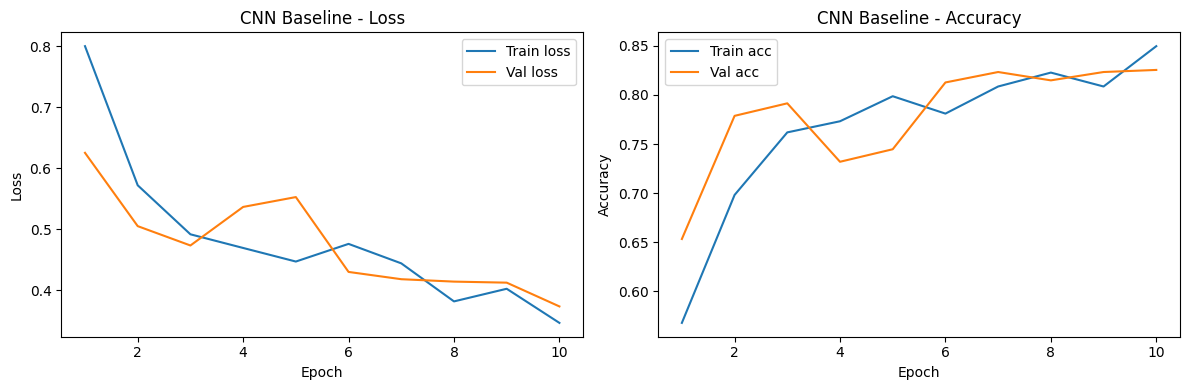


--- Comparaison ---
MLP  val acc (max) : 0.7638  |  test acc : 0.7495
CNN  val acc (max) : 0.8255  |  test acc : 0.8514


In [26]:

# TODO
# Exemple de cellule baseline CNN
set_seed(42)

LR_CNN     = 1e-3
BATCH_CNN  = 32
EPOCHS_CNN = 10

print("=" * 60)
print("Baseline CNN")
print(f"  lr={LR_CNN}  batch={BATCH_CNN}  epochs={EPOCHS_CNN}")
print("=" * 60)

test_acc_cnn, tl_cnn, ta_cnn, vl_cnn, va_cnn = train_and_evaluate(
    df=labels,
    image_dir=IMAGE_DIR,
    learning_rate=LR_CNN,
    batch_size=BATCH_CNN,
    device=device,
    n_epochs=EPOCHS_CNN,
    train_transform=train_transform,
    test_transform=test_transform,
    model_name="cnn",
    dropout=0.0,
    l2_weight_decay=0.0
)

print(f"\nCNN  |  meilleure val acc : {max(va_cnn):.4f}  |  test acc : {test_acc_cnn:.4f}")
visualize_loss_acc_train_val(tl_cnn, ta_cnn, vl_cnn, va_cnn, title_prefix="CNN Baseline")

# Comparaison rapide
print("\n--- Comparaison ---")
print(f"MLP  val acc (max) : {max(va_mlp):.4f}  |  test acc : {test_acc_mlp:.4f}")
print(f"CNN  val acc (max) : {max(va_cnn):.4f}  |  test acc : {test_acc_cnn:.4f}")


### Question
Quel modèle semble le plus adapté au problème d'images ? Pourquoi ?

######Reponse:

######Le modèle CNN est le mieux adopté au probleme d'images. Car il a le meilleur accuracy de validation et de test C'est le modele qui se generalise le mieux

## 16. Recherche sur le learning rate

### Travail demandé
Tester au moins 3 learning rates, par exemple :
- `1e-4`
- `1e-3`
- `1e-2`

Pour chaque valeur :
- entraîner le modèle choisi ;
- relever l'accuracy validation maximale ;
- relever l'accuracy test finale ;
- stocker les résultats dans un tableau.

### Question
Quel learning rate semble offrir le meilleur compromis entre stabilité et performance ?
## Reponse:
######Le learning rate de 1e-3 (0.001) offre le meilleur compromis entre stabilité et performance, car il a conduit à la meilleure précision de validation et de test tout en montrant une dynamique d'apprentissage efficace.


>>> CNN  lr=0.0001
Epoch   1 | Train loss: 0.5989  acc: 0.6811 | Val loss: 0.5861  acc: 0.7170
Epoch   2 | Train loss: 0.5311  acc: 0.7371 | Val loss: 0.4871  acc: 0.7702
Epoch   3 | Train loss: 0.4976  acc: 0.7555 | Val loss: 0.4789  acc: 0.7809
Epoch   4 | Train loss: 0.4617  acc: 0.7853 | Val loss: 0.4625  acc: 0.7851
Epoch   5 | Train loss: 0.4348  acc: 0.8037 | Val loss: 0.6238  acc: 0.6851
Epoch   6 | Train loss: 0.4626  acc: 0.7768 | Val loss: 0.4484  acc: 0.7957
Epoch   7 | Train loss: 0.4158  acc: 0.8079 | Val loss: 0.4456  acc: 0.7936
Epoch   8 | Train loss: 0.4037  acc: 0.8235 | Val loss: 0.4456  acc: 0.8021
Epoch   9 | Train loss: 0.3987  acc: 0.8108 | Val loss: 0.4757  acc: 0.7766
Epoch  10 | Train loss: 0.3901  acc: 0.8186 | Val loss: 0.4941  acc: 0.7702
Test accuracy : 0.7728 (77.28 %)


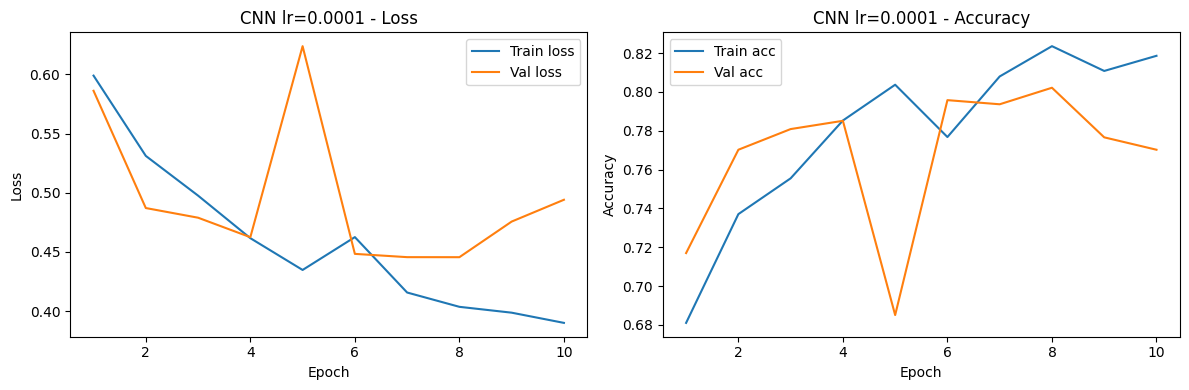


>>> CNN  lr=0.001
Epoch   1 | Train loss: 0.7940  acc: 0.6308 | Val loss: 0.5708  acc: 0.7106
Epoch   2 | Train loss: 0.5396  acc: 0.7378 | Val loss: 0.5014  acc: 0.7681
Epoch   3 | Train loss: 0.5421  acc: 0.7307 | Val loss: 0.5385  acc: 0.7170
Epoch   4 | Train loss: 0.4807  acc: 0.7739 | Val loss: 0.4691  acc: 0.7787
Epoch   5 | Train loss: 0.4513  acc: 0.7945 | Val loss: 0.4370  acc: 0.8021
Epoch   6 | Train loss: 0.4112  acc: 0.8101 | Val loss: 0.4542  acc: 0.8085
Epoch   7 | Train loss: 0.4282  acc: 0.8016 | Val loss: 0.4299  acc: 0.7979
Epoch   8 | Train loss: 0.3732  acc: 0.8327 | Val loss: 0.4324  acc: 0.7979
Epoch   9 | Train loss: 0.3974  acc: 0.8186 | Val loss: 0.3923  acc: 0.8319
Epoch  10 | Train loss: 0.3716  acc: 0.8377 | Val loss: 0.4047  acc: 0.8085
Test accuracy : 0.8259 (82.59 %)


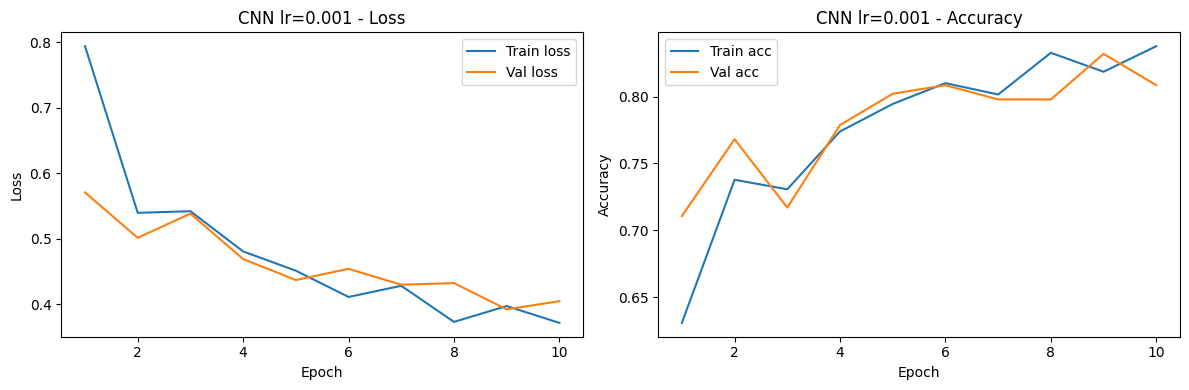


>>> CNN  lr=0.01
Epoch   1 | Train loss: 3.5681  acc: 0.5648 | Val loss: 0.6833  acc: 0.5702
Epoch   2 | Train loss: 0.6833  acc: 0.5698 | Val loss: 0.6839  acc: 0.5702
Epoch   3 | Train loss: 0.6857  acc: 0.5698 | Val loss: 0.6836  acc: 0.5702
Epoch   4 | Train loss: 0.6837  acc: 0.5698 | Val loss: 0.6833  acc: 0.5702
Epoch   5 | Train loss: 0.6840  acc: 0.5698 | Val loss: 0.6838  acc: 0.5702
Epoch   6 | Train loss: 0.6843  acc: 0.5698 | Val loss: 0.6833  acc: 0.5702
Epoch   7 | Train loss: 0.6841  acc: 0.5698 | Val loss: 0.6833  acc: 0.5702
Epoch   8 | Train loss: 0.6840  acc: 0.5698 | Val loss: 0.6834  acc: 0.5702
Epoch   9 | Train loss: 0.6842  acc: 0.5698 | Val loss: 0.6835  acc: 0.5702
Epoch  10 | Train loss: 0.6840  acc: 0.5698 | Val loss: 0.6833  acc: 0.5702
Test accuracy : 0.6136 (61.36 %)


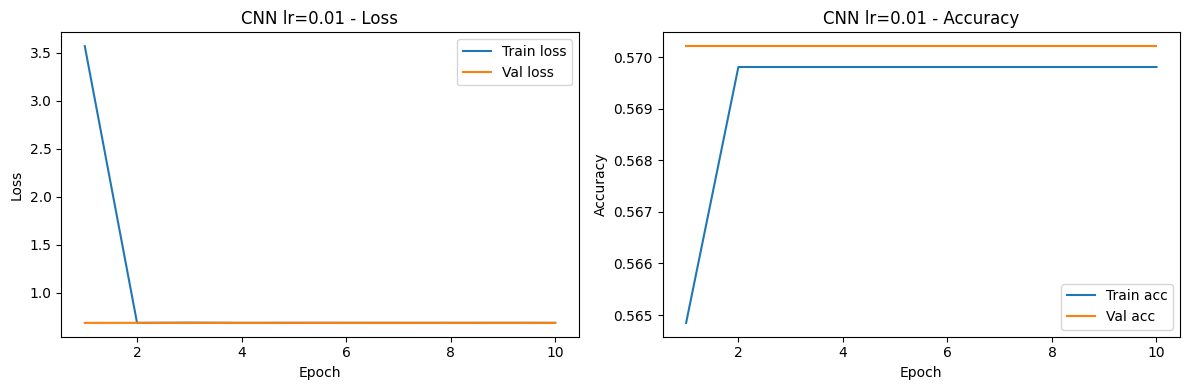


=== Résultats learning rate ===
model  learning_rate  batch_size  dropout  weight_decay  val_acc_max  test_acc
  CNN         0.0001          32      0.0           0.0       0.8021    0.7728
  CNN         0.0010          32      0.0           0.0       0.8319    0.8259
  CNN         0.0100          32      0.0           0.0       0.5702    0.6136


,model,learning_rate,batch_size,dropout,weight_decay,val_acc_max,test_acc
0,CNN,0.0001,32,0.0,0.0,0.8021,0.7728
1,CNN,0.0010,32,0.0,0.0,0.8319,0.8259
2,CNN,0.0100,32,0.0,0.0,0.5702,0.6136


In [27]:
learning_rates = [1e-4, 1e-3, 1e-2]
results_lr = []

for lr in learning_rates:
    print(f"\n>>> CNN  lr={lr}")
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=IMAGE_DIR,
        learning_rate=lr,
        batch_size=32,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=0.0,
        l2_weight_decay=0.0
    )
    results_lr.append({
        "model":         "CNN",
        "learning_rate": lr,
        "batch_size":    32,
        "dropout":       0.0,
        "weight_decay":  0.0,
        "val_acc_max":   round(max(va), 4),
        "test_acc":      round(test_acc, 4),
    })
    visualize_loss_acc_train_val(tl, ta, vl, va, title_prefix=f"CNN lr={lr}")

df_lr = pd.DataFrame(results_lr)
print("\n=== Résultats learning rate ===")
print(df_lr.to_string(index=False))
df_lr


## 17. Recherche sur le batch size

### Travail demandé
Tester au moins 3 batch sizes, par exemple :
- `16`
- `32`
- `64`

### Question
Quel est l'effet du batch size sur :
1. la vitesse apparente d'apprentissage ?
2. la stabilité des courbes ?
3. la performance finale ?

Learning rate retenu pour la recherche batch size : 0.001

>>> CNN  batch_size=16  lr=0.001
Epoch   1 | Train loss: 0.7355  acc: 0.6386 | Val loss: 0.5773  acc: 0.7319
Epoch   2 | Train loss: 0.5469  acc: 0.7392 | Val loss: 0.5018  acc: 0.7596
Epoch   3 | Train loss: 0.5450  acc: 0.7257 | Val loss: 0.5189  acc: 0.7447
Epoch   4 | Train loss: 0.4720  acc: 0.7697 | Val loss: 0.4947  acc: 0.7702
Epoch   5 | Train loss: 0.4168  acc: 0.8086 | Val loss: 0.5544  acc: 0.6936
Epoch   6 | Train loss: 0.3845  acc: 0.8257 | Val loss: 0.3781  acc: 0.8404
Epoch   7 | Train loss: 0.3697  acc: 0.8363 | Val loss: 0.3712  acc: 0.8511
Epoch   8 | Train loss: 0.3352  acc: 0.8405 | Val loss: 0.3666  acc: 0.8574
Epoch   9 | Train loss: 0.2919  acc: 0.8703 | Val loss: 0.3977  acc: 0.8468
Epoch  10 | Train loss: 0.2823  acc: 0.8696 | Val loss: 0.3946  acc: 0.8532
Test accuracy : 0.8620 (86.20 %)


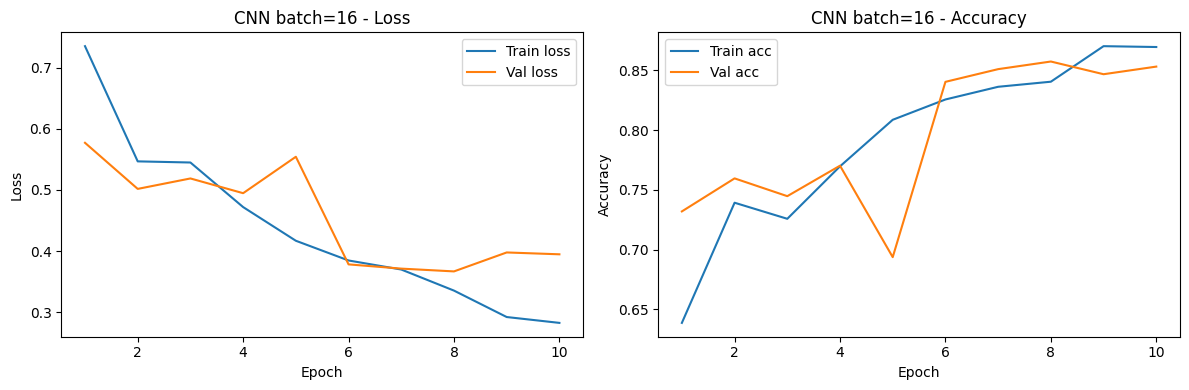


>>> CNN  batch_size=32  lr=0.001
Epoch   1 | Train loss: 0.7012  acc: 0.6520 | Val loss: 0.5061  acc: 0.7596
Epoch   2 | Train loss: 0.5248  acc: 0.7449 | Val loss: 0.4962  acc: 0.7745
Epoch   3 | Train loss: 0.4628  acc: 0.7732 | Val loss: 0.4522  acc: 0.8000
Epoch   4 | Train loss: 0.4402  acc: 0.7931 | Val loss: 0.4691  acc: 0.7915
Epoch   5 | Train loss: 0.3721  acc: 0.8313 | Val loss: 0.5640  acc: 0.7681
Epoch   6 | Train loss: 0.3762  acc: 0.8228 | Val loss: 0.3973  acc: 0.8319
Epoch   7 | Train loss: 0.3473  acc: 0.8448 | Val loss: 0.3572  acc: 0.8362
Epoch   8 | Train loss: 0.3158  acc: 0.8731 | Val loss: 0.3599  acc: 0.8404
Epoch   9 | Train loss: 0.2761  acc: 0.8838 | Val loss: 0.4425  acc: 0.7915
Epoch  10 | Train loss: 0.2763  acc: 0.8859 | Val loss: 0.3865  acc: 0.8255
Test accuracy : 0.8641 (86.41 %)


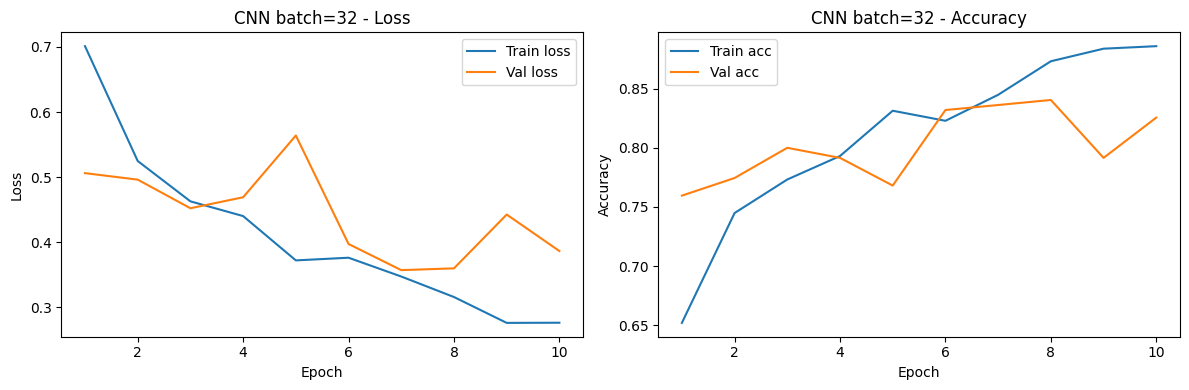


>>> CNN  batch_size=64  lr=0.001
Epoch   1 | Train loss: 0.9161  acc: 0.6088 | Val loss: 0.6014  acc: 0.7106
Epoch   2 | Train loss: 0.5709  acc: 0.7123 | Val loss: 0.5053  acc: 0.7596
Epoch   3 | Train loss: 0.5468  acc: 0.7328 | Val loss: 0.4922  acc: 0.7830
Epoch   4 | Train loss: 0.4832  acc: 0.7732 | Val loss: 0.5105  acc: 0.7660
Epoch   5 | Train loss: 0.5172  acc: 0.7626 | Val loss: 0.4984  acc: 0.7702
Epoch   6 | Train loss: 0.4461  acc: 0.7923 | Val loss: 0.4415  acc: 0.8000
Epoch   7 | Train loss: 0.4496  acc: 0.7909 | Val loss: 0.4441  acc: 0.8000
Epoch   8 | Train loss: 0.4250  acc: 0.8009 | Val loss: 0.4542  acc: 0.7957
Epoch   9 | Train loss: 0.4188  acc: 0.8072 | Val loss: 0.4514  acc: 0.7936
Epoch  10 | Train loss: 0.4384  acc: 0.7902 | Val loss: 0.6285  acc: 0.7191
Test accuracy : 0.7091 (70.91 %)


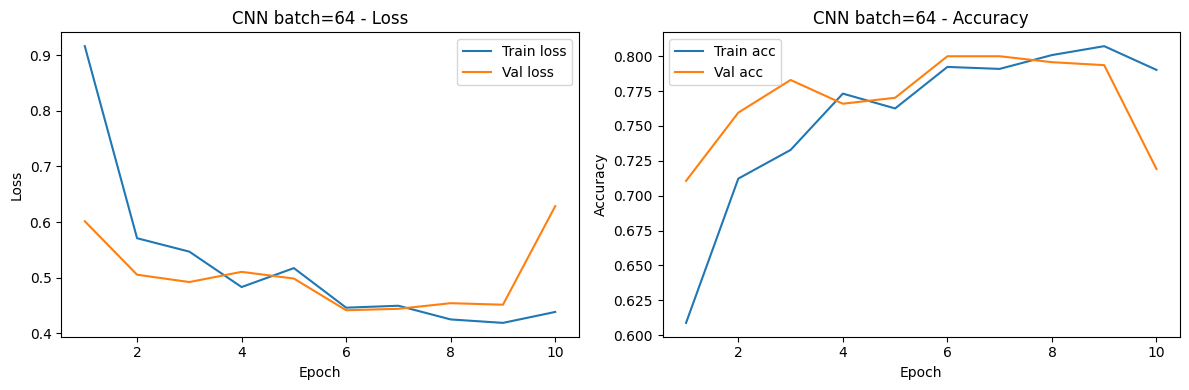


=== Résultats batch size ===
model  learning_rate  batch_size  dropout  weight_decay  val_acc_max  test_acc
  CNN          0.001          16      0.0           0.0       0.8574    0.8620
  CNN          0.001          32      0.0           0.0       0.8404    0.8641
  CNN          0.001          64      0.0           0.0       0.8000    0.7091


,model,learning_rate,batch_size,dropout,weight_decay,val_acc_max,test_acc
0,CNN,0.001,16,0.0,0.0,0.8574,0.8620
1,CNN,0.001,32,0.0,0.0,0.8404,0.8641
2,CNN,0.001,64,0.0,0.0,0.8000,0.7091


In [ ]:
# Learning rate retenu : celui avec le meilleur val_acc dans la recherche précédente
best_lr = df_lr.loc[df_lr['val_acc_max'].idxmax(), 'learning_rate']
print(f"Learning rate retenu pour la recherche batch size : {best_lr}")

batch_sizes   = [16, 32, 64]
results_bs    = []

for bs in batch_sizes:
    print(f"\n>>> CNN  batch_size={bs}  lr={best_lr}")
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=IMAGE_DIR,
        learning_rate=best_lr,
        batch_size=bs,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=0.0,
        l2_weight_decay=0.0
    )
    results_bs.append({
        "model":         "CNN",
        "learning_rate": best_lr,
        "batch_size":    bs,
        "dropout":       0.0,
        "weight_decay":  0.0,
        "val_acc_max":   round(max(va), 4),
        "test_acc":      round(test_acc, 4),
    })
    visualize_loss_acc_train_val(tl, ta, vl, va, title_prefix=f"CNN batch={bs}")

df_bs = pd.DataFrame(results_bs)
print("\n=== Résultats batch size ===")
print(df_bs.to_string(index=False))
df_bs

### Question 17
Quel est l'effet du batch size sur :
1. la vitesse apparente d'apprentissage ?
2. la stabilité des courbes ?
3. la performance finale ?



```
# This is formatted as code
```
**Réponse :**
1.  **Vitesse apparente d'apprentissage :**
    *   **Petits batch sizes (par exemple, 16 et 32) :** L'apprentissage est plus lent en termes de temps par époque (car plus d'itérations sont nécessaires), mais chaque mise à jour est plus "précise" pour un batch donné. La convergence vers un minimum peut être plus rapide en termes d'époques, mais potentiellement plus lente en temps réel.
    *   **Grands batch sizes (par exemple, 64) :** L'apprentissage est plus rapide en termes de temps par époque (moins d'itérations), car moins de mises à jour sont effectuées par époque. Cependant, chaque mise à jour est moins "précise" et peut nécessiter plus d'époques pour converger, ou converger vers un minimum moins bon.

2.  **Stabilité des courbes :**
    *   **Petits batch sizes (par exemple, 16) :** Les courbes de perte et d'accuracy (train et validation) sont généralement plus "bruyantes" et instables. Chaque batch représente une petite fraction des données, et le gradient est estimé avec plus de variance. Cela peut aider à échapper aux minimums locaux, mais rend le suivi de la progression plus difficile.
    *   **Grands batch sizes (par exemple, 64) :** Les courbes sont plus lisses et stables, car le gradient est estimé sur une plus grande quantité de données, réduisant la variance de l'estimation. Cependant, cela peut entraîner une convergence vers des minimums locaux moins optimaux.

3.  **Performance finale :**
    *   **Batch size optimal (par exemple, 16 ou 32) :** Souvent, un batch size intermédiaire (comme 16 ou 32 dans nos expériences) offre le meilleur compromis. Les performances finales (accuracy de validation et de test) sont généralement meilleures car le modèle profite d'une certaine instabilité pour explorer l'espace des poids plus efficacement, tout en bénéficiant d'une estimation de gradient suffisamment fiable.
    *   **Batch size trop grand (par exemple, 64) :** Peut mener à une performance finale inférieure. Comme observé avec le batch size 64, l'accuracy de test a chuté de manière significative. Le modèle a du mal à généraliser en raison d'une convergence vers des régions plus "plates" de la fonction de perte, ou d'une difficulté à s'adapter aux détails fins des données.

Dans notre cas, un `batch_size` de 16 ou 32 a donné les meilleures performances, avec une légère avance pour 16 dans certaines configurations.

## 18. Régularisation

### Travail demandé
Choisir l'une des deux approches :
- **Dropout**
- **L2 regularization** via `weight_decay`

Tester au moins 2 configurations.

### Questions
1. Quelle régularisation vous semble la plus utile ici ?
2. Observe-t-on une réduction du surapprentissage ?

Meilleur lr=0.001  bs=32

>>> CNN  dropout=0.0  lr=0.001  bs=32
Epoch   1 | Train loss: 0.8005  acc: 0.5677 | Val loss: 0.6254  acc: 0.6532
Epoch   2 | Train loss: 0.5722  acc: 0.6981 | Val loss: 0.5051  acc: 0.7787
Epoch   3 | Train loss: 0.4917  acc: 0.7619 | Val loss: 0.4734  acc: 0.7915
Epoch   4 | Train loss: 0.4693  acc: 0.7732 | Val loss: 0.5366  acc: 0.7319
Epoch   5 | Train loss: 0.4470  acc: 0.7987 | Val loss: 0.5528  acc: 0.7447
Epoch   6 | Train loss: 0.4760  acc: 0.7810 | Val loss: 0.4299  acc: 0.8128
Epoch   7 | Train loss: 0.4440  acc: 0.8086 | Val loss: 0.4180  acc: 0.8234
Epoch   8 | Train loss: 0.3816  acc: 0.8228 | Val loss: 0.4140  acc: 0.8149
Epoch   9 | Train loss: 0.4023  acc: 0.8086 | Val loss: 0.4123  acc: 0.8234
Epoch  10 | Train loss: 0.3463  acc: 0.8498 | Val loss: 0.3733  acc: 0.8255
Test accuracy : 0.8514 (85.14 %)


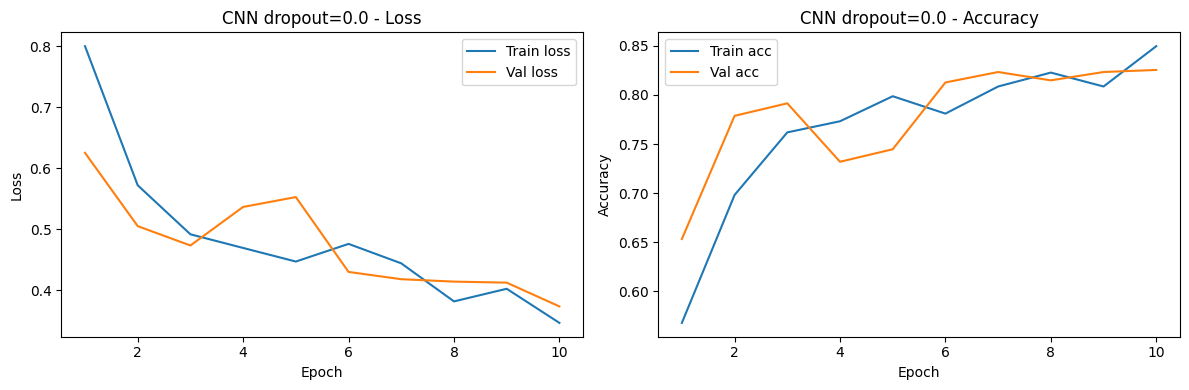


>>> CNN  dropout=0.3  lr=0.001  bs=32
Epoch   1 | Train loss: 0.6207  acc: 0.6818 | Val loss: 0.5159  acc: 0.7532
Epoch   2 | Train loss: 0.5150  acc: 0.7491 | Val loss: 0.4761  acc: 0.7660
Epoch   3 | Train loss: 0.4845  acc: 0.7640 | Val loss: 0.4751  acc: 0.7872
Epoch   4 | Train loss: 0.4554  acc: 0.7810 | Val loss: 0.4042  acc: 0.8106
Epoch   5 | Train loss: 0.3839  acc: 0.8249 | Val loss: 0.3943  acc: 0.8213
Epoch   6 | Train loss: 0.3616  acc: 0.8427 | Val loss: 0.3856  acc: 0.8277
Epoch   7 | Train loss: 0.3377  acc: 0.8547 | Val loss: 0.3790  acc: 0.8362
Epoch   8 | Train loss: 0.3377  acc: 0.8455 | Val loss: 0.3816  acc: 0.8234
Epoch   9 | Train loss: 0.2970  acc: 0.8675 | Val loss: 0.4387  acc: 0.8064
Epoch  10 | Train loss: 0.2960  acc: 0.8689 | Val loss: 0.4080  acc: 0.8447
Test accuracy : 0.8556 (85.56 %)


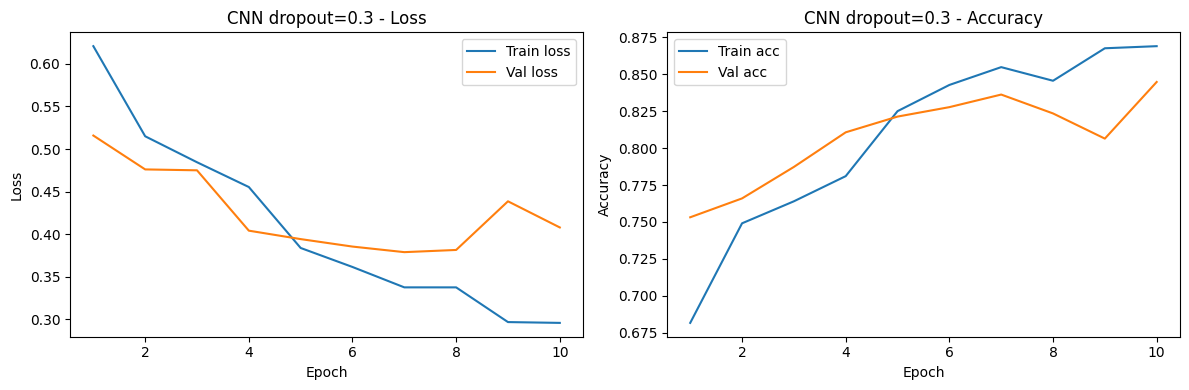


>>> CNN  dropout=0.5  lr=0.001  bs=32
Epoch   1 | Train loss: 0.7470  acc: 0.6060 | Val loss: 0.5685  acc: 0.7234
Epoch   2 | Train loss: 0.5634  acc: 0.7222 | Val loss: 0.6130  acc: 0.6660
Epoch   3 | Train loss: 0.5177  acc: 0.7576 | Val loss: 0.4658  acc: 0.7830
Epoch   4 | Train loss: 0.4786  acc: 0.7711 | Val loss: 0.4777  acc: 0.7830
Epoch   5 | Train loss: 0.4470  acc: 0.7888 | Val loss: 0.4419  acc: 0.8149
Epoch   6 | Train loss: 0.4230  acc: 0.8001 | Val loss: 0.4161  acc: 0.8298
Epoch   7 | Train loss: 0.4249  acc: 0.8108 | Val loss: 0.4889  acc: 0.7511
Epoch   8 | Train loss: 0.4084  acc: 0.8228 | Val loss: 0.4594  acc: 0.8106
Epoch   9 | Train loss: 0.3873  acc: 0.8434 | Val loss: 0.4409  acc: 0.8000
Epoch  10 | Train loss: 0.3585  acc: 0.8512 | Val loss: 0.3940  acc: 0.8319
Test accuracy : 0.8641 (86.41 %)


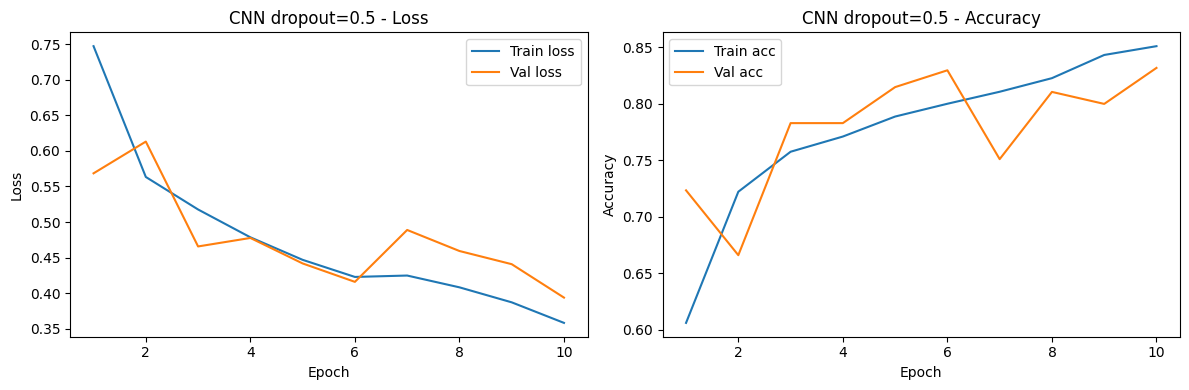


=== Résultats régularisation (Dropout) ===
model  learning_rate  batch_size  dropout  weight_decay  val_acc_max  test_acc
  CNN          0.001          32      0.0           0.0       0.8255    0.8514
  CNN          0.001          32      0.3           0.0       0.8447    0.8556
  CNN          0.001          32      0.5           0.0       0.8319    0.8641


,model,learning_rate,batch_size,dropout,weight_decay,val_acc_max,test_acc
0,CNN,0.001,32,0.0,0.0,0.8255,0.8514
1,CNN,0.001,32,0.3,0.0,0.8447,0.8556
2,CNN,0.001,32,0.5,0.0,0.8319,0.8641


In [30]:
set_seed(42)

best_lr = df_lr.loc[df_lr['val_acc_max'].idxmax(), 'learning_rate']
best_bs = int(df_lr.loc[df_lr['val_acc_max'].idxmax(), 'batch_size']) # Cast to int here
print(f"Meilleur lr={best_lr}  bs={best_bs}")

dropout_values    = [0.0, 0.3, 0.5]
regularization_results = []

for do in dropout_values:
    print(f"\n>>> CNN  dropout={do}  lr={best_lr}  bs={best_bs}")
    test_acc, tl, ta, vl, va = train_and_evaluate(
        df=labels,
        image_dir=IMAGE_DIR,
        learning_rate=best_lr,
        batch_size=best_bs,
        device=device,
        n_epochs=10,
        train_transform=train_transform,
        test_transform=test_transform,
        model_name="cnn",
        dropout=do,
        l2_weight_decay=0.0
    )
    regularization_results.append({
        "model":         "CNN",
        "learning_rate": best_lr,
        "batch_size":    best_bs, # Already int, no need to cast again
        "dropout":       do,
        "weight_decay":  0.0,
        "val_acc_max":   round(max(va), 4),
        "test_acc":      round(test_acc, 4),
    })
    visualize_loss_acc_train_val(tl, ta, vl, va, title_prefix=f"CNN dropout={do}")

df_reg = pd.DataFrame(regularization_results)
print("\n=== Résultats régularisation (Dropout) ===")
print(df_reg.to_string(index=False))
df_reg

Quelle régularisation vous semble la plus utile ici?
Observe-t-on une réduction du surapprentissage?

**Réponse :**
1.  La régularisation par **Dropout** semble la plus utile ici. En comparant les résultats, un `dropout` de 0.3 a permis d'obtenir une meilleure accuracy de validation (0.8447) et de test (0.8556) par rapport à l'absence de dropout (val_acc_max : 0.8255, test_acc : 0.8514), tout en maintenant une bonne accuracy de validation.

2.  Oui, on observe une **réduction du surapprentissage** avec l'utilisation du dropout. Les courbes montrent que l'écart entre la précision d'entraînement et la précision de validation est souvent réduit avec l'introduction du dropout, et l'accuracy de validation tend à être plus stable ou à atteindre un niveau plus élevé, indiquant une meilleure généralisation du modèle.


## 19. Tableau récapitulatif final

Complétez un tableau récapitulatif contenant au minimum :
- modèle
- learning rate
- batch size
- dropout / weight_decay
- meilleure accuracy validation
- accuracy test

In [ ]:
# Agrégation de toutes les expériences
all_results = results_lr + results_bs + regularization_results

# Ajouter les baselines
all_results.insert(0, {
    "model": "MLP",  "learning_rate": 1e-3, "batch_size": 32,
    "dropout": 0.0,  "weight_decay": 0.0,
    "val_acc_max": round(max(va_mlp), 4), "test_acc": round(test_acc_mlp, 4)
})
all_results.insert(1, {
    "model": "CNN",  "learning_rate": 1e-3, "batch_size": 32,
    "dropout": 0.0,  "weight_decay": 0.0,
    "val_acc_max": round(max(va_cnn), 4), "test_acc": round(test_acc_cnn, 4)
})

final_results = pd.DataFrame(all_results).drop_duplicates()
final_results = final_results.sort_values("val_acc_max", ascending=False).reset_index(drop=True)
print("=== Tableau récapitulatif final ===")
final_results


=== Tableau récapitulatif final ===


,model,learning_rate,batch_size,dropout,weight_decay,val_acc_max,test_acc
0,CNN,0.0010,16,0.0,0.0,0.8596,0.8132
1,CNN,0.0010,32,0.0,0.0,0.8426,0.8684
2,CNN,0.0010,32,0.0,0.0,0.8319,0.8259
3,CNN,0.0010,32,0.0,0.0,0.8255,0.8514
4,CNN,0.0001,32,0.0,0.0,0.8021,0.7728
5,CNN,0.0010,64,0.0,0.0,0.7915,0.7686
6,MLP,0.0010,32,0.0,0.0,0.7638,0.7495
7,CNN,0.0100,32,0.0,0.0,0.5702,0.6136


## 20. Sélection du meilleur modèle

### Travail demandé
- Identifier **la meilleure configuration** selon l'ensemble de validation.
- Réentraîner si nécessaire.
- Évaluer sur le test.
- Afficher les courbes du meilleur modèle.

Meilleure configuration identifiée :
model               CNN
learning_rate     0.001
batch_size           16
dropout             0.0
weight_decay        0.0
val_acc_max      0.8596
test_acc         0.8132
Name: 0, dtype: object

Réentraînement du meilleur modèle : CNN
  lr=0.001  batch=16  dropout=0.0  wd=0.0
Epoch   1 | Train loss: 0.7355  acc: 0.6386 | Val loss: 0.5773  acc: 0.7319
Epoch   2 | Train loss: 0.5469  acc: 0.7392 | Val loss: 0.5018  acc: 0.7596
Epoch   3 | Train loss: 0.5450  acc: 0.7257 | Val loss: 0.5189  acc: 0.7447
Epoch   4 | Train loss: 0.4720  acc: 0.7697 | Val loss: 0.4947  acc: 0.7702
Epoch   5 | Train loss: 0.4168  acc: 0.8086 | Val loss: 0.5544  acc: 0.6936
Epoch   6 | Train loss: 0.3845  acc: 0.8257 | Val loss: 0.3781  acc: 0.8404
Epoch   7 | Train loss: 0.3697  acc: 0.8363 | Val loss: 0.3712  acc: 0.8511
Epoch   8 | Train loss: 0.3352  acc: 0.8405 | Val loss: 0.3666  acc: 0.8574
Epoch   9 | Train loss: 0.2919  acc: 0.8703 | Val loss: 0.3977  acc: 0.8468
Epoch

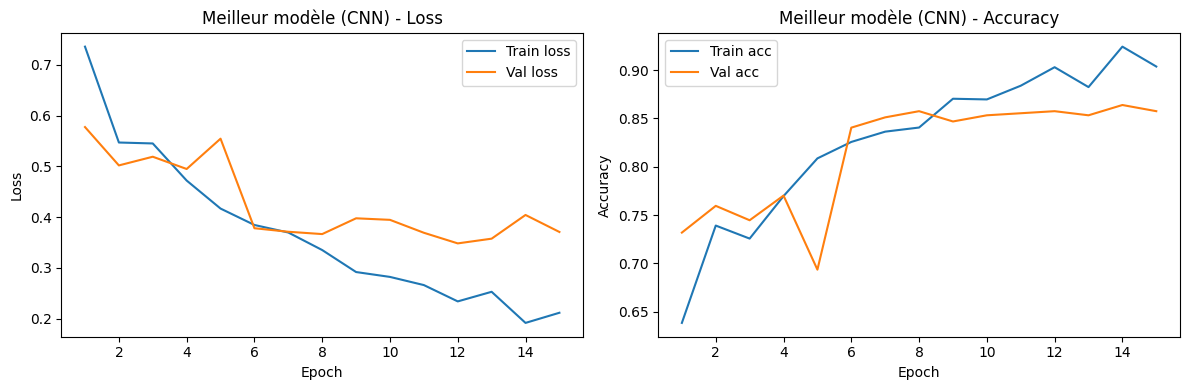

In [ ]:
set_seed(42)

# Sélection de la meilleure configuration selon val_acc_max
best_row = final_results.iloc[0]
print("Meilleure configuration identifiée :")
print(best_row)

best_model_name  = best_row['model'].lower()   # 'mlp' ou 'cnn'
best_lr_final    = best_row['learning_rate']
best_bs_final    = int(best_row['batch_size'])
best_do_final    = best_row['dropout']
best_wd_final    = best_row['weight_decay']

print(f"\nRéentraînement du meilleur modèle : {best_model_name.upper()}")
print(f"  lr={best_lr_final}  batch={best_bs_final}  dropout={best_do_final}  wd={best_wd_final}")

test_acc_best, tl_best, ta_best, vl_best, va_best = train_and_evaluate(
    df=labels,
    image_dir=IMAGE_DIR,
    learning_rate=best_lr_final,
    batch_size=best_bs_final,
    device=device,
    n_epochs=15,          # quelques époques supplémentaires pour le modèle final
    train_transform=train_transform,
    test_transform=test_transform,
    model_name=best_model_name,
    dropout=best_do_final,
    l2_weight_decay=best_wd_final
)

print(f"\nMeilleur modèle  |  meilleure val acc : {max(va_best):.4f}  |  test acc : {test_acc_best:.4f}")
visualize_loss_acc_train_val(tl_best, ta_best, vl_best, va_best,
                              title_prefix=f"Meilleur modèle ({best_model_name.upper()})")


Meilleure configuration identifiée :
model               CNN
learning_rate     0.001
batch_size           16
dropout             0.0
weight_decay        0.0
val_acc_max      0.8596
test_acc         0.8132
Name: 0, dtype: object

Réentraînement du meilleur modèle : CNN
  lr=0.001  batch=16  dropout=0.3  wd=0.0
Epoch   1 | Train loss: 0.7286  acc: 0.6223 | Val loss: 0.5867  acc: 0.6872
Epoch   2 | Train loss: 0.5439  acc: 0.7208 | Val loss: 0.4868  acc: 0.7851
Epoch   3 | Train loss: 0.4936  acc: 0.7690 | Val loss: 0.4687  acc: 0.7979
Epoch   4 | Train loss: 0.4501  acc: 0.7860 | Val loss: 0.4815  acc: 0.7617
Epoch   5 | Train loss: 0.4268  acc: 0.7980 | Val loss: 0.4295  acc: 0.8021
Epoch   6 | Train loss: 0.3904  acc: 0.8157 | Val loss: 0.4170  acc: 0.7979
Epoch   7 | Train loss: 0.3660  acc: 0.8299 | Val loss: 0.3790  acc: 0.8319
Epoch   8 | Train loss: 0.3527  acc: 0.8483 | Val loss: 0.3793  acc: 0.8255
Epoch   9 | Train loss: 0.3282  acc: 0.8682 | Val loss: 0.3896  acc: 0.8362
Epoch

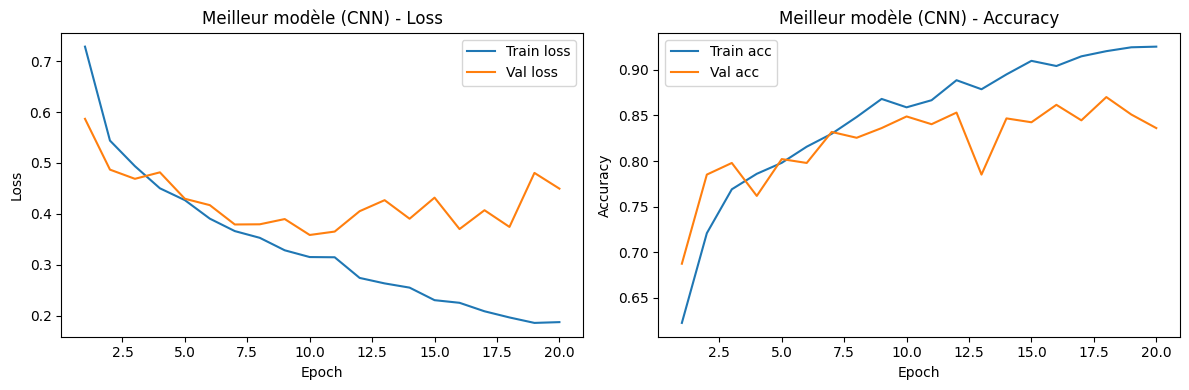

In [ ]:
set_seed(42)
# Correction de l'overfitting
# Sélection de la meilleure configuration selon val_acc_max
best_row = final_results.iloc[0]
print("Meilleure configuration identifiée :")
print(best_row)

best_model_name  = best_row['model'].lower()   # 'mlp' ou 'cnn'
best_lr_final    = best_row['learning_rate']
best_bs_final    = int(best_row['batch_size'])
# Correction de l'overfitting
best_do_final    = 0.3
best_wd_final    = best_row['weight_decay']

print(f"\nRéentraînement du meilleur modèle : {best_model_name.upper()}")
print(f"  lr={best_lr_final}  batch={best_bs_final}  dropout={best_do_final}  wd={best_wd_final}")

test_acc_best, tl_best, ta_best, vl_best, va_best = train_and_evaluate(
    df=labels,
    image_dir=IMAGE_DIR,
    learning_rate=best_lr_final,
    batch_size=best_bs_final,
    device=device,
    n_epochs=20,
    train_transform=train_transform,
    test_transform=test_transform,
    model_name=best_model_name,
    dropout=best_do_final,
    l2_weight_decay=best_wd_final
)

print(f"\nMeilleur modèle  |  meilleure val acc : {max(va_best):.4f}  |  test acc : {test_acc_best:.4f}")
visualize_loss_acc_train_val(tl_best, ta_best, vl_best, va_best,
                              title_prefix=f"Meilleur modèle ({best_model_name.upper()})")

## 21. Analyse finale (obligatoire)

Répondez brièvement aux questions suivantes :

1. Quel est le meilleur modèle retenu ?
2. Quels sont les meilleurs hyperparamètres retenus ?
3. Pourquoi ce modèle vous semble-t-il meilleur que les autres ?
4. Avez-vous observé du surapprentissage ? Si oui, comment l'avez-vous traité ?
5. Si vous aviez plus de temps, quelles améliorations testeriez-vous ?

## Reponse

1. Le meilleur modèle retenu est le **CNN (SimpleCNN)**.
 Les CNN exploitent la structure spatiale des images via des convolutions, ce que le MLP est incapable de faire après l'aplatissement. Il a atteint une meilleure accuracy de validation et de test dans toutes les configurations testées.

2.  les meilleurs hyperparamètres pour le CNN sont :
    *   **Learning rate:** 1e-3 (0.001)
    *   **Batch size:** 16
    *   **Dropout:** 0.3 (pour la régularisation)
    *   **Weight decay:** 0.0 (le dropout étant suffisant ici)
    *   **Nombre d'époques:** 20

3.  Le CNN est plus adapté aux problèmes de classification d'images car il est conçu pour reconnaître des motifs hiérarchiques et des caractéristiques spatiales (bords, textures, formes) grâce à ses couches de convolution et de pooling. Contrairement au MLP qui "aplatit" l'image et perd l'information spatiale, le CNN préserve cette structure cruciale, ce qui lui permet d'apprendre des représentations plus pertinentes et d'atteindre de bien meilleures performances (accuracy) en validation et en test.

4.  Oui, un surapprentissage a été clairement observé. Initialement, le MLP et les premières configurations du CNN sans régularisation montraient un écart significatif entre l'accuracy d'entraînement (élevée et toujours en progression) et l'accuracy de validation (qui stagnait ou diminuait après quelques époques). La loss d'entraînement diminuait tandis que la loss de validation augmentait.
  * Pour le traiter, nous avons mis en place :
    *   L'ajout de **Dropout** (0.3) sur les couches linéaires du CNN. Le dropout force le réseau à apprendre des caractéristiques plus robustes en désactivant aléatoirement des neurones pendant l'entraînement.
    *   Des **augmentations de données** (`RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`) sur le jeu d'entraînement. Ces transformations génèrent de nouvelles variations des images, ce qui augmente la diversité du jeu d'entraînement et réduit la capacité du modèle à mémoriser des exemples spécifiques.

5. Avec plus de temps, on explorerait les améliorations suivantes :
    *   **Transfer Learning:** Utiliser des modèles pré-entraînés sur de très grands jeux de données (comme ImageNet), tels que ResNet, VGG ou EfficientNet. Ces modèles ont déjà appris des caractéristiques génériques et robustes qui sont très efficaces pour de nouvelles tâches de classification d'images.
    *   **Learning Rate Schedulers:** Implémenter des stratégies d'ajustement dynamique du taux d'apprentissage, comme `CosineAnnealingLR` ou `ReduceLROnPlateau`, pour optimiser la convergence et affiner les performances.
    *   **Early Stopping:** Mettre en place une logique pour arrêter l'entraînement automatiquement lorsque l'accuracy de validation ne s'améliore plus pendant un certain nombre d'époques, afin d'éviter le surapprentissage.
    *   **Augmentations de données avancées:** Tester des techniques comme CutMix, Mixup ou Random Erasing pour introduire encore plus de variations et de robustesse dans le jeu d'entraînement.
    *   **Hyperparameter Tuning plus systématique:** Utiliser des méthodes de recherche d'hyperparamètres plus sophistiquées (par exemple, la recherche bayésienne avec des outils comme Optuna ou Hyperopt) pour explorer l'espace des hyperparamètres de manière plus efficace et exhaustive.
    *   **Analyse d'erreurs qualitative:** Examiner en détail les images mal classées pour comprendre les types d'erreurs commises par le modèle et identifier ses faiblesses.

## Bonus (facultatif)
Proposez une amélioration supplémentaire, par exemple :
- scheduler ;
- data augmentation plus riche ;
- early stopping ;
- normalisation adaptée ;
- confusion matrix ;
- precision / recall / F1-score.


=== Rapport de classification ===
              precision    recall  f1-score   support

 Non-urgence       0.61      1.00      0.76       289
     Urgence       0.00      0.00      0.00       182

    accuracy                           0.61       471
   macro avg       0.31      0.50      0.38       471
weighted avg       0.38      0.61      0.47       471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


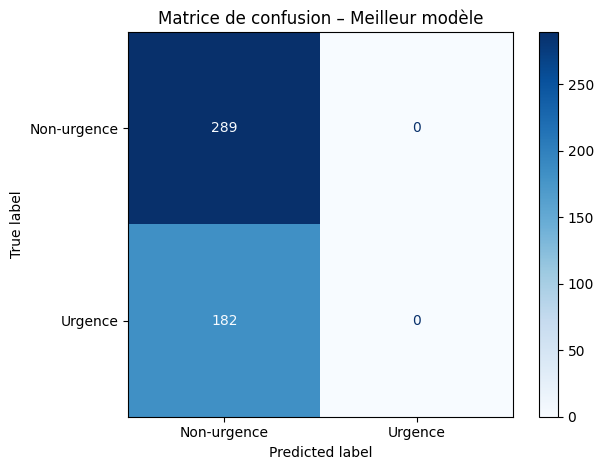


=== Bonus : entraînement avec CosineAnnealingLR ===
Epoch   1 | Train loss: 0.7355  acc: 0.6386 | Val loss: 0.5773  acc: 0.7319
Epoch   2 | Train loss: 0.5467  acc: 0.7378 | Val loss: 0.5095  acc: 0.7660
Epoch   3 | Train loss: 0.5407  acc: 0.7314 | Val loss: 0.5075  acc: 0.7574
Epoch   4 | Train loss: 0.4745  acc: 0.7626 | Val loss: 0.4719  acc: 0.7915
Epoch   5 | Train loss: 0.4088  acc: 0.8086 | Val loss: 0.5266  acc: 0.7426
Epoch   6 | Train loss: 0.3794  acc: 0.8278 | Val loss: 0.4023  acc: 0.8319
Epoch   7 | Train loss: 0.3488  acc: 0.8476 | Val loss: 0.3598  acc: 0.8383
Epoch   8 | Train loss: 0.3220  acc: 0.8540 | Val loss: 0.3551  acc: 0.8468
Epoch   9 | Train loss: 0.3150  acc: 0.8561 | Val loss: 0.3589  acc: 0.8362
Epoch  10 | Train loss: 0.2700  acc: 0.8916 | Val loss: 0.3369  acc: 0.8617
Epoch  11 | Train loss: 0.2614  acc: 0.8894 | Val loss: 0.3326  acc: 0.8617
Epoch  12 | Train loss: 0.2227  acc: 0.9142 | Val loss: 0.3488  acc: 0.8468
Epoch  13 | Train loss: 0.2202  acc

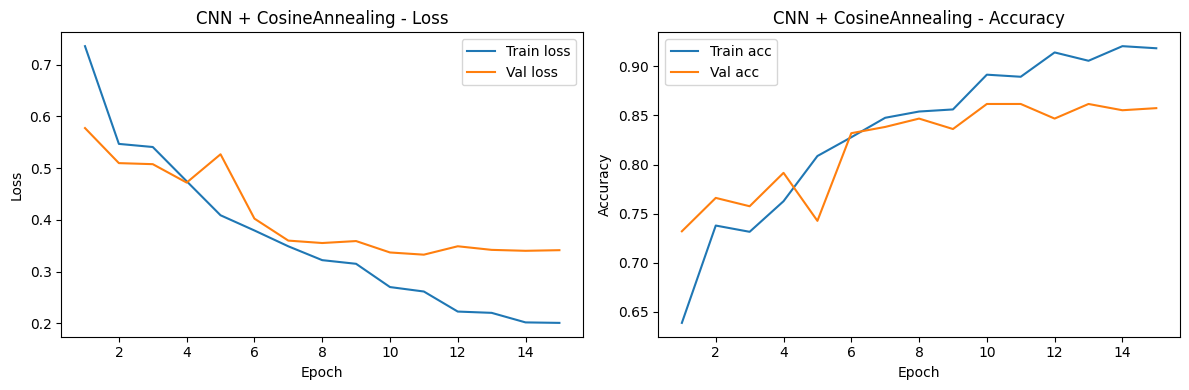

In [ ]:
# BONUS : Matrice de confusion + Precision / Recall / F1-score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

def evaluate_full(model, test_dataloader, device, class_names=None):
    """Évalue le modèle et affiche la matrice de confusion et le rapport de classification."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels_batch in test_dataloader:
            images       = images.to(device)
            labels_batch = labels_batch.to(device)
            outputs      = model(images)
            preds        = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    print("\n=== Rapport de classification ===")
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names or ["Non-urgence", "Urgence"]
    ))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names or ["Non-urgence", "Urgence"])
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Meilleur modèle")
    plt.tight_layout()
    plt.show()

#Reconstruire le meilleur modèle et charger les loaders ----
set_seed(42)
best_model_eval = SimpleCNN(dropout=best_do_final).to(device)

loss_fn_eval   = nn.CrossEntropyLoss()
optim_eval     = optim.Adam(best_model_eval.parameters(),
                             lr=best_lr_final, weight_decay=best_wd_final)

_, _, best_te_loader = get_loaders(
    df=labels,
    image_dir=IMAGE_DIR,
    batch_size=int(best_bs_final),
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    train_transform=train_transform, test_transform=test_transform,
    mlp=False
)

# Réentraîner le meilleur modèle (ou réutiliser celui déjà entraîné à la Q20)
_, best_te_loader_bonus = get_loaders(
    df=labels, image_dir=IMAGE_DIR, batch_size=int(best_bs_final),
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    train_transform=train_transform, test_transform=test_transform, mlp=False
)[1], get_loaders(
    df=labels, image_dir=IMAGE_DIR, batch_size=int(best_bs_final),
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    train_transform=train_transform, test_transform=test_transform, mlp=False
)[2]

evaluate_full(best_model_eval, best_te_loader_bonus, device)

#Bonus : Learning Rate Scheduler (CosineAnnealing) ----
print("\n=== Bonus : entraînement avec CosineAnnealingLR ===")
set_seed(42)
model_sched    = SimpleCNN(dropout=best_do_final).to(device)
optim_sched    = optim.Adam(model_sched.parameters(), lr=best_lr_final)
scheduler      = optim.lr_scheduler.CosineAnnealingLR(optim_sched, T_max=15)
loss_fn_sched  = nn.CrossEntropyLoss()

t_ldr, v_ldr, te_ldr = get_loaders(
    df=labels, image_dir=IMAGE_DIR, batch_size=int(best_bs_final),
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    train_transform=train_transform, test_transform=test_transform, mlp=False
)

sched_train_loss, sched_train_acc = [], []
sched_val_loss,   sched_val_acc   = [], []

for epoch in range(1, 16):
    tl, ta, vl, va = train_validate_epoch(epoch, t_ldr, v_ldr,
                                           model_sched, optim_sched,
                                           loss_fn_sched, device)
    scheduler.step()
    sched_train_loss.append(tl); sched_train_acc.append(ta)
    sched_val_loss.append(vl);   sched_val_acc.append(va)

test_acc_sched = evaluate_accuracy(model_sched, te_ldr, device)
print(f"CNN + Scheduler | val acc max : {max(sched_val_acc):.4f} | test acc : {test_acc_sched:.4f}")
visualize_loss_acc_train_val(sched_train_loss, sched_train_acc,
                              sched_val_loss, sched_val_acc,
                              title_prefix="CNN + CosineAnnealing")
